Please upload your 3 images (Shapes, Natural Scene, Text/QR):


<>:97: SyntaxWarning: invalid escape sequence '\s'
<>:97: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2573787587.py:97: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"$\sigma$={s['sigma']}, T={s['thresh']}\nNoise: {s['noise']}")


Saving WhatsApp Image 2025-12-18 at 14.59.36.jpeg to WhatsApp Image 2025-12-18 at 14.59.36 (3).jpeg


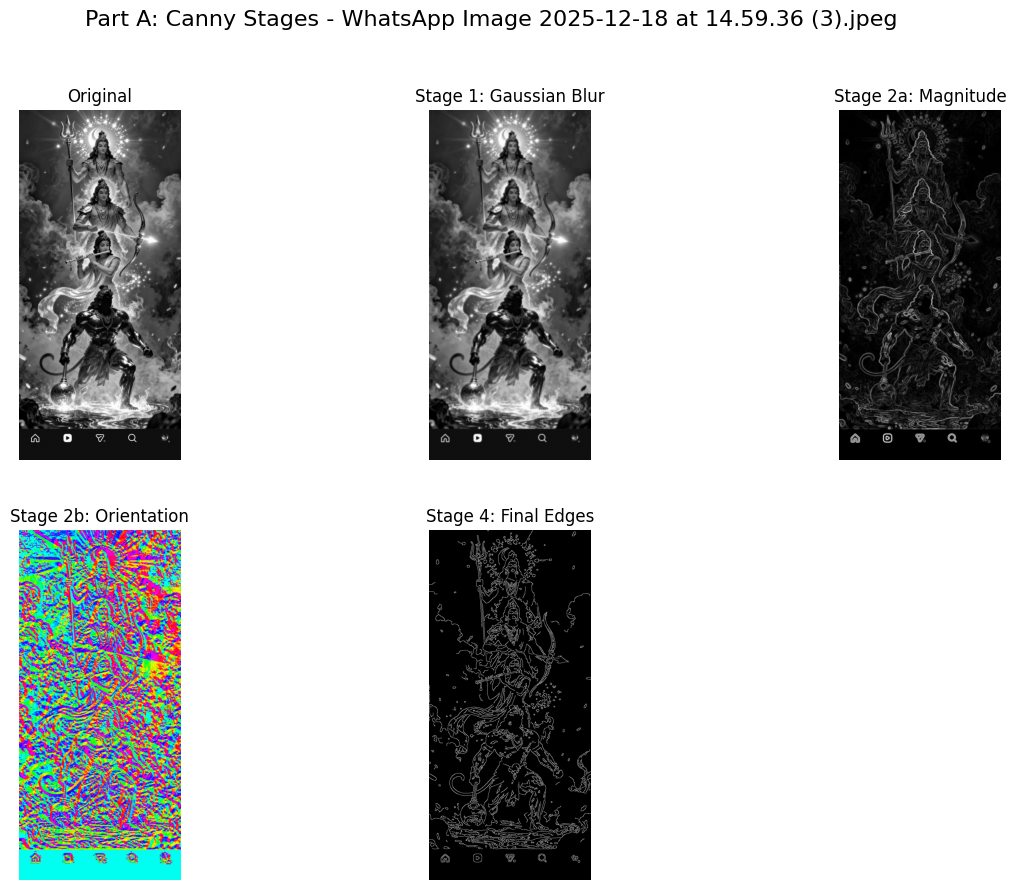

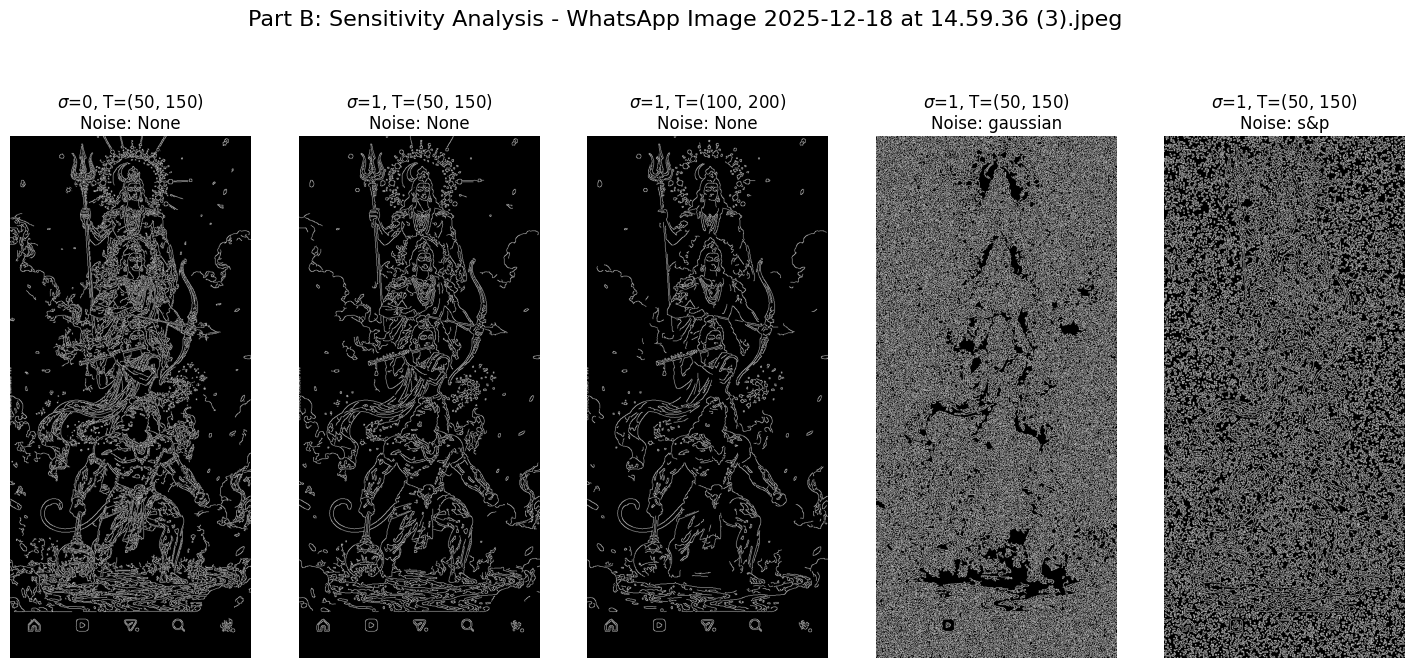

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- 1. Upload Images ---
print("Please upload your 3 images (Shapes, Natural Scene, Text/QR):")
uploaded = files.upload()
filenames = list(uploaded.keys())

def run_lab_4_part_A(img_path):
    # Load image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return

    # Stage 1: Gaussian Blur
    # We use a 5x5 kernel as standard for Canny
    stage1 = cv2.GaussianBlur(img, (5, 5), 1.4)

    # Stage 2: Sobel Gradients
    grad_x = cv2.Sobel(stage1, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(stage1, cv2.CV_64F, 0, 1, ksize=3)

    # 2a: Magnitude
    mag = np.sqrt(grad_x**2 + grad_y**2)
    # 2b: Orientation (atan2 returns values in radians)
    orient = np.arctan2(grad_y, grad_x)

    # Stage 3 & 4: Manual breakdown is complex, so we use OpenCV's Canny
    # to demonstrate the final thinning (NMS) and Hysteresis.
    # Note: OpenCV's Canny combines NMS and Hysteresis internally.
    low_threshold = 50
    high_threshold = 150
    final_edges = cv2.Canny(stage1, low_threshold, high_threshold)

    # Visualization
    plt.figure(figsize=(15, 10))
    plt.suptitle(f"Part A: Canny Stages - {img_path}", fontsize=16)

    titles = ['Original', 'Stage 1: Gaussian Blur', 'Stage 2a: Magnitude',
              'Stage 2b: Orientation', 'Stage 4: Final Edges']
    images = [img, stage1, mag, orient, final_edges]

    for i in range(5):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i], cmap='gray' if i != 3 else 'hsv')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

def add_noise(img, noise_type="gaussian"):
    if noise_type == "gaussian":
        mean = 0
        sigma = 25
        gauss = np.random.normal(mean, sigma, img.shape).astype('uint8')
        return cv2.add(img, gauss)
    elif noise_type == "s&p":
        # Salt and Pepper
        out = np.copy(img)
        prob = 0.05
        thres = 1 - prob
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                rdn = np.random.random()
                if rdn < prob: out[i][j] = 0
                elif rdn > thres: out[i][j] = 255
        return out

def run_lab_4_part_B(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Testing scenarios as per Step 17-20
    scenarios = [
        {"sigma": 0, "thresh": (50, 150), "noise": None},
        {"sigma": 1, "thresh": (50, 150), "noise": None},
        {"sigma": 1, "thresh": (100, 200), "noise": None},
        {"sigma": 1, "thresh": (50, 150), "noise": "gaussian"},
        {"sigma": 1, "thresh": (50, 150), "noise": "s&p"}
    ]

    plt.figure(figsize=(18, 8))
    plt.suptitle(f"Part B: Sensitivity Analysis - {img_path}", fontsize=16)

    for i, s in enumerate(scenarios):
        # 1. Add Noise if required
        processed = add_noise(img, s["noise"]) if s["noise"] else img.copy()

        # 2. Apply Blur
        if s["sigma"] > 0:
            processed = cv2.GaussianBlur(processed, (5, 5), s["sigma"])

        # 3. Apply Canny
        edges = cv2.Canny(processed, s["thresh"][0], s["thresh"][1])

        plt.subplot(1, 5, i+1)
        plt.imshow(edges, cmap='gray')
        plt.title(f"$\sigma$={s['sigma']}, T={s['thresh']}\nNoise: {s['noise']}")
        plt.axis('off')
    plt.show()

# --- Execution ---
for img_name in filenames:
    run_lab_4_part_A(img_name)
    run_lab_4_part_B(img_name)